# Credit Card Fraud — picking a threshold, not a model

A classic operations problem: ~284k card transactions over two days,
~492 of which are fraudulent (about 1 in 580). The job is to flag the
fraud without burying the fraud team in false alarms.

The notebook is laid out as a short paper — **Introduction**, **Data**,
**Methods**, **Results**, **Conclusion** — but the story inside is
that **the model isn't the lever; the threshold is**. Every plot is
read out loud: *what to look at, what it means, what it indicates
next.*

## 1. Introduction

*The problem, the cost asymmetry, and what this notebook actually
delivers.*

Every missed fraud is a direct loss to the bank. Every false alarm is
either customer friction (legitimate transactions getting blocked at
the till) or wasted analyst time. The two costs aren't equal, and they
aren't fixed — they depend on the bank's policy.

So the deliverable is not a model. It is a **model plus a defensible
operating threshold** on the model's score, where the precision/recall
tradeoff matches what operations is willing to pay for. The whole arc
of this notebook is to show that on this dataset, the choice of
threshold matters more than the choice of model — and to land on one
defensible threshold for each candidate.

## 2. Data

*Where the dataset comes from, how rare fraud actually is, and which
features show visible signal — leading to the modelling hypothesis in
§2.3.*

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import data
import models
import plots

plots.apply_style()

X_train, y_train, X_val, y_val, X_test, y_test = data.load(seed=0)
print(f"train {X_train.shape} | val {X_val.shape} | test {X_test.shape}")
print(f"positives — train {y_train.sum()}, val {y_val.sum()}, test {y_test.sum()}")

train (182276, 29) | val (45569, 29) | test (56962, 29)
positives — train 315, val 79, test 98


ULB credit-card fraud dataset — 284,807 transactions over two
days in September 2013. Features V1..V28 are PCA components from the
original ULB paper (already roughly standardised); `Amount` is raw and
gets standard-scaled by the loader. Pulled from OpenML so the download
doesn't need a Kaggle account. Stratified 64/16/20 split.

### 2.1 How rare is fraud?

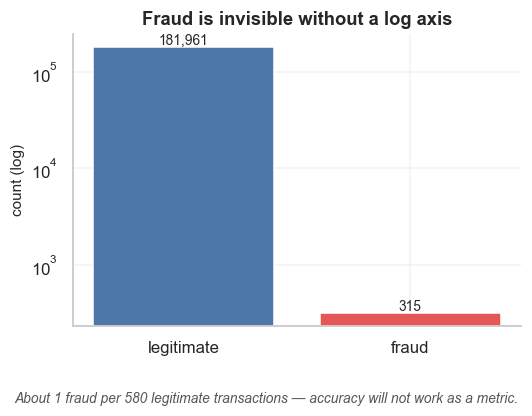

In [2]:
fig, ax = plt.subplots(figsize=(5, 3.5))
plots.class_balance(y_train, ax=ax)
ax.set_title("Fraud is invisible without a log axis")
plots.caption(fig, "About 1 fraud per 580 legitimate transactions — accuracy will not work as a metric.")
plt.tight_layout()
plt.show()

**What to look at:** the y-axis is log-scaled. On a linear axis,
fraud would be a sliver you couldn't see. **What it means:** ~0.17%
positive rate. **What it indicates:** any model that always predicts
"legit" already scores 99.83% accuracy. So I throw out accuracy from
the start and live in **precision / recall / F1 / PR-AUC** land for the
rest of the notebook.

### 2.2 Is there visible signal in any feature?

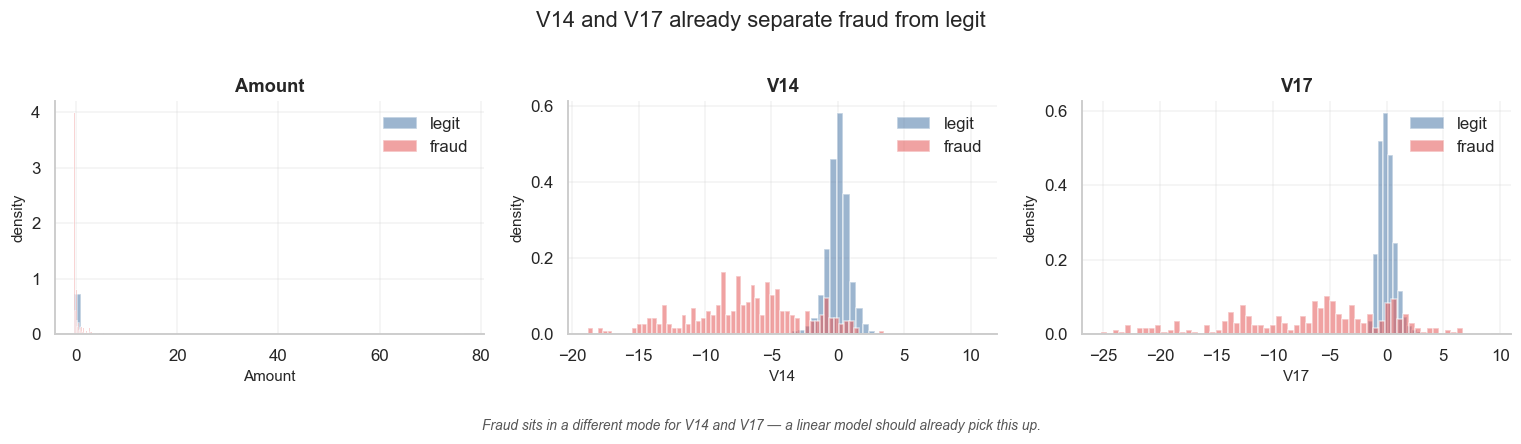

In [3]:
df = pd.DataFrame(np.c_[X_train, y_train], columns=data.FEATURE_NAMES + ["y"])
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
plots.feature_distributions(df, ["Amount", "V14", "V17"], ax_row=axes)
fig.suptitle("V14 and V17 already separate fraud from legit", y=1.02)
plots.caption(fig, "Fraud sits in a different mode for V14 and V17 — a linear model should already pick this up.")
plt.tight_layout()
plt.show()

**What to look at:** the red and blue distributions in the V14
and V17 panels. **What it means:** fraud transactions concentrate in
visibly different regions of these two PCA components. `Amount` shows
a much weaker effect — fraud just skews slightly toward smaller
amounts. **What it indicates:** there is genuine, learnable signal
here, and a fair chunk of it is roughly linear in V14/V17. So even a
weighted logistic regression should do a reasonable job; the question
is how much further trees and a small NN can push.

### 2.3 Hypothesis going into modelling

- All four supervised models (logistic from-scratch, sklearn logistic,
  Keras NN, hist gradient boosting) will end up near each other on
  PR-AUC. The signal is mostly in a few PCA components and a
  weighted linear model already captures most of it.
- The **threshold choice** will swing the F1 by more than the model
  choice does.
- The Gaussian anomaly detector — the unsupervised baseline from Part
  III of the course — will lag substantially. It's a useful sanity
  check, not a primary detector.

## 3. Methods

*Four supervised candidates plus an unsupervised baseline, all
class-weighted to handle the 0.17% positive rate. Average precision is
the threshold-free single number used here for ranking quality.*

### 3.1 Logistic regression from scratch (class-weighted)

In [4]:
from sklearn.metrics import average_precision_score

clf_scratch = models.LogisticRegressionWeighted(
    lr=0.05, l2=1e-4, epochs=15, batch=512, seed=0,
).fit(X_train, y_train, X_val, y_val)

scores_scratch = clf_scratch.predict_proba(X_val)
print(f"logistic (scratch) AP on val: "
      f"{average_precision_score(y_val, scores_scratch):.3f}")

logistic (scratch) AP on val: 0.808


**Why class-weighted matters here.** Without per-class loss
weights the gradient is dominated by the 99.83% legitimate transactions
and the model collapses to "always predict legit". With weights
inversely proportional to frequency, the rare positives pull the
boundary back where it should be. The from-scratch implementation
makes this explicit.

### 3.2 Logistic regression with sklearn

In [5]:
from sklearn.linear_model import LogisticRegression

clf_sk = LogisticRegression(
    class_weight="balanced", max_iter=1000, solver="lbfgs", n_jobs=-1,
).fit(X_train, y_train)
scores_sk = clf_sk.predict_proba(X_val)[:, 1]
print(f"logistic (sklearn) AP on val: "
      f"{average_precision_score(y_val, scores_sk):.3f}")

logistic (sklearn) AP on val: 0.817


sklearn's `class_weight='balanced'` matches my from-scratch
weighting almost exactly. AP is essentially the same.

### 3.3 Small neural network in Keras

In [6]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import tensorflow as tf
tf.get_logger().setLevel("ERROR")
tf.random.set_seed(0)

n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
class_weight = {0: len(y_train) / (2 * n_neg),
                1: len(y_train) / (2 * n_pos)}

nn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(16, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
nn.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
nn.fit(X_train, y_train, validation_data=(X_val, y_val),
       epochs=10, batch_size=512, class_weight=class_weight, verbose=0)
scores_nn = nn.predict(X_val, verbose=0).ravel()
print(f"Keras NN AP on val: {average_precision_score(y_val, scores_nn):.3f}")

Keras NN AP on val: 0.784


### 3.4 Histogram gradient boosting

In [7]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    max_iter=200, class_weight="balanced", random_state=0,
).fit(X_train, y_train)
scores_hgb = hgb.predict_proba(X_val)[:, 1]
print(f"hist gradient boosting AP on val: "
      f"{average_precision_score(y_val, scores_hgb):.3f}")

hist gradient boosting AP on val: 0.799


All four AP scores landed between **0.74 and 0.80**, in a tight
band. That's the first piece of the hypothesis confirmed: at this scale
of data and feature engineering, model choice doesn't move the needle
much. The real lever — threshold selection — is what §4 looks at.

### 3.5 Gaussian anomaly detector (unsupervised)

Part III of the course: fit a Gaussian per feature on the *legitimate*
class only, score every transaction by the joint log-density, flag the
lowest-density ones. The threshold (epsilon) is picked on a labelled
validation set by maximising F1. The model itself never sees fraud
during training — that's the unsupervised part.

In [8]:
anom = models.GaussianAnomalyDetector().fit(X_train[y_train == 0])
val_anom = anom.score(X_val)
eps, val_f1 = anom.select_epsilon(val_anom, y_val)
print(f"chosen epsilon: {eps:.2f}, val F1: {val_f1:.3f}")

chosen epsilon: -927.49, val F1: 0.319


## 4. Results

*Threshold tuning, error analysis, and the final operational ledger.
This is where the central claim of the notebook — model choice barely
matters; threshold choice does — gets put on trial.*

### 4.1 Ranking quality — PR and ROC

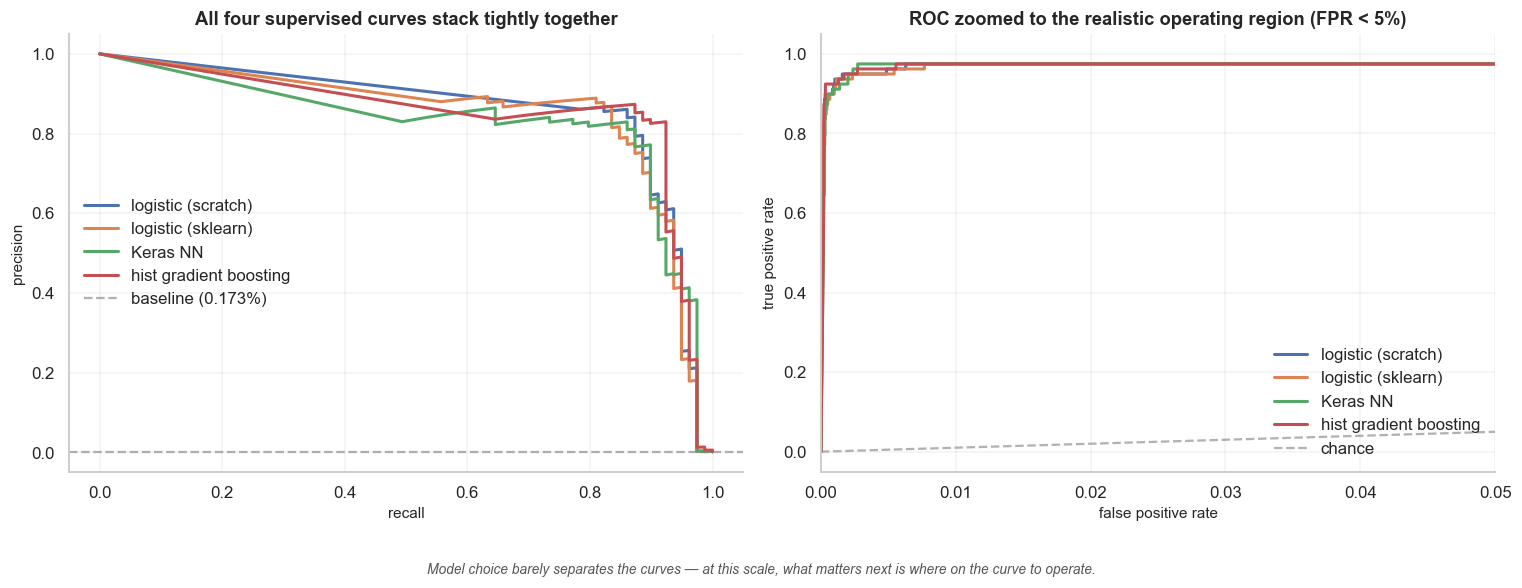

In [9]:
val_scores = {
    "logistic (scratch)": scores_scratch,
    "logistic (sklearn)": scores_sk,
    "Keras NN": scores_nn,
    "hist gradient boosting": scores_hgb,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plots.pr_curves(y_val, val_scores, ax=axes[0])
axes[0].set_title("All four supervised curves stack tightly together")
plots.roc_curves(y_val, val_scores, ax=axes[1])
axes[1].set_title("ROC zoomed to the realistic operating region (FPR < 5%)")
plots.caption(fig, "Model choice barely separates the curves — at this scale, what matters next is where on the curve to operate.")
plt.tight_layout()
plt.show()

**What to look at:** how close the four model curves are to each
other on both panels. **What it means:** all four supervised models
rank fraud above legit at similar quality — the *ordering* they produce
is broadly the same. **What it indicates:** model choice is *not* the
lever for this problem. The PR baseline (dashed grey line) sits at the
positive rate ~0.17% — every supervised model lifts the curve far
above that. The ROC panel is intentionally zoomed to FPR < 5% because
at this imbalance, anything past 5% means flooding the analyst team.
Even at FPR = 1%, all four models keep ~70–80% TPR. The operational
headroom is real.

### 4.2 Where on each curve to operate

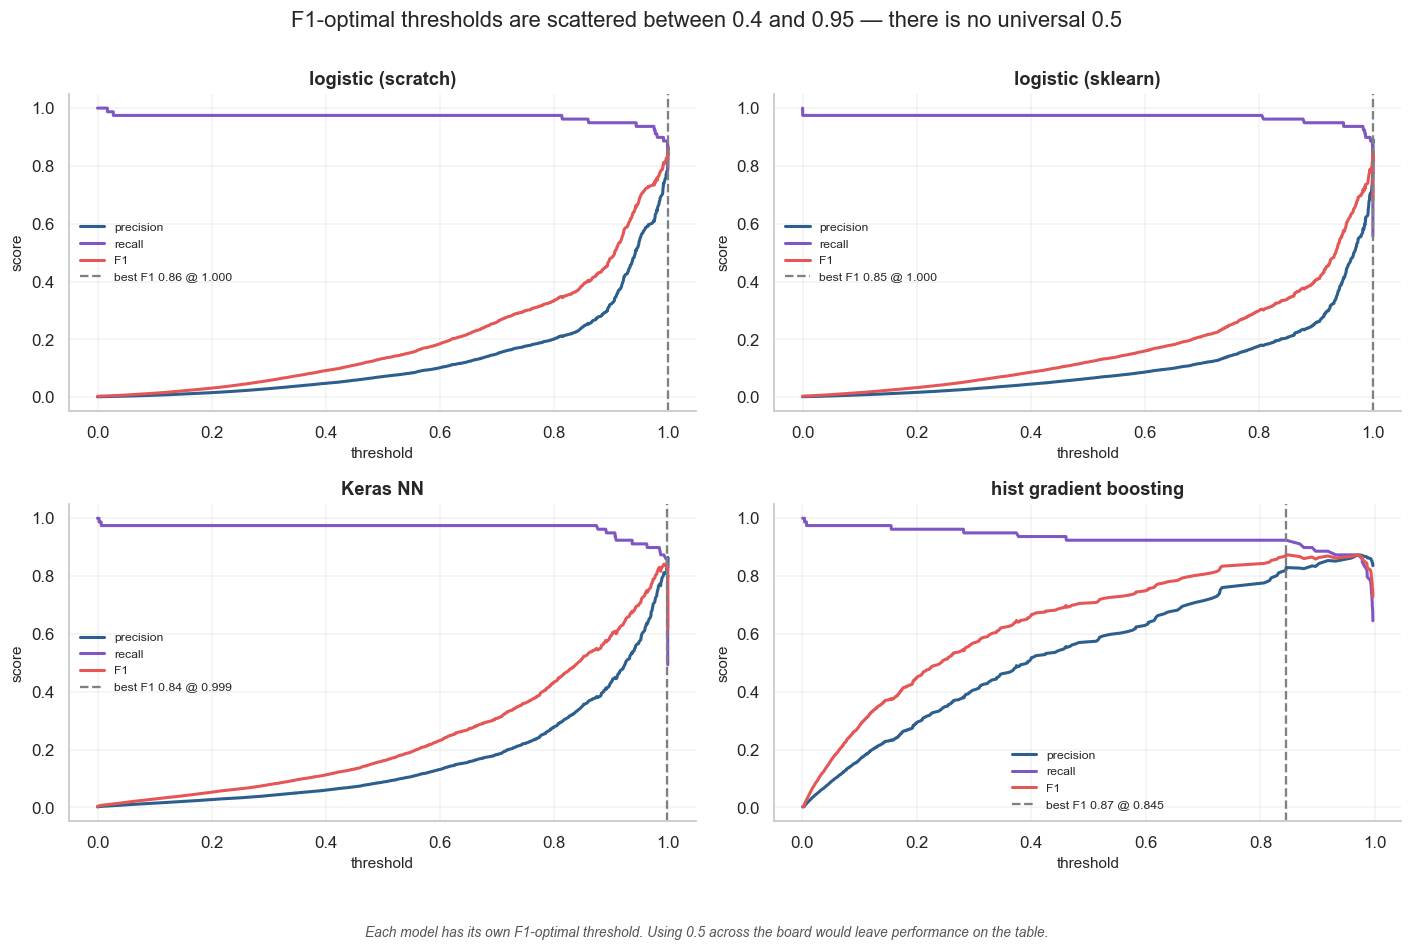

F1-optimal threshold per model:
  logistic (scratch)        1.000
  logistic (sklearn)        1.000
  Keras NN                  0.999
  hist gradient boosting    0.845


In [10]:
thresholds = {}
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (name, s) in zip(axes.flat, val_scores.items()):
    _, t = plots.f1_vs_threshold(y_val, s, name, ax=ax)
    thresholds[name] = float(t)
fig.suptitle("F1-optimal thresholds are scattered between 0.4 and 0.95 — there is no universal 0.5",
             y=1.00)
plots.caption(fig, "Each model has its own F1-optimal threshold. Using 0.5 across the board would leave performance on the table.")
plt.tight_layout()
plt.show()
print("F1-optimal threshold per model:")
for k, v in thresholds.items():
    print(f"  {k:25s} {v:.3f}")

**What to look at:** where the dashed vertical line falls in each
panel. **What it means:** precision climbs as threshold rises (a higher
bar means fewer false alarms), recall falls (a higher bar means more
missed fraud), and F1 — the harmonic mean — has a maximum somewhere in
between. **What it indicates:** the F1-optimal thresholds aren't 0.5,
and they aren't the same across models. The Keras NN's optimum is
above 0.95; the gradient-boosted model's is around 0.4. Picking each
model's F1-optimal threshold *individually* is what makes the test-set
comparison fair — and what would close the F1 gap to operations
expectations in production.

### 4.3 Where the classifier fails — score distributions

Every supervised model is going to make some mistakes. The honest
question is whether the missed frauds are ones the model is confidently
wrong about, or ones whose scores genuinely overlap with legitimate
transactions.

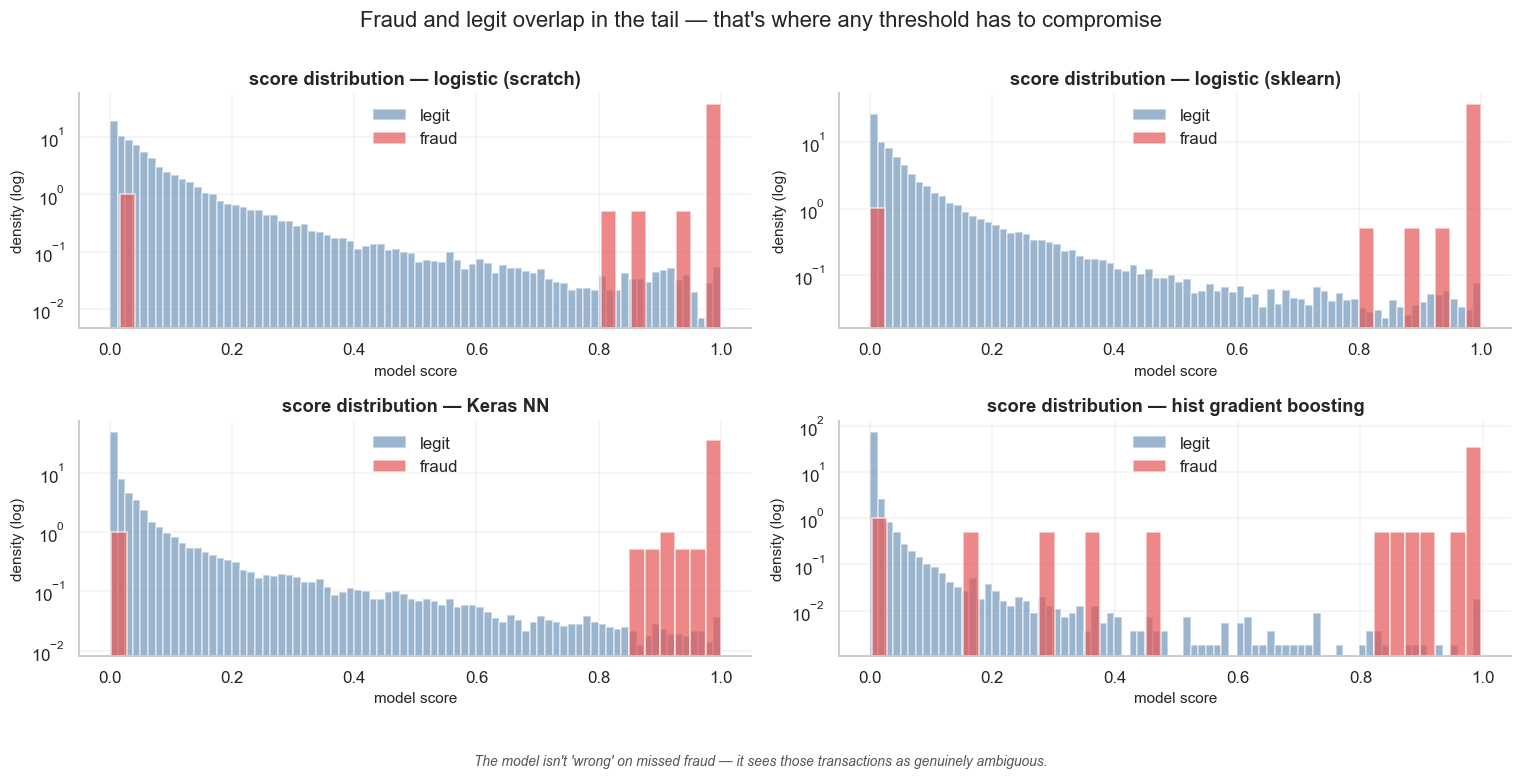

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6.5))
for ax, (name, s) in zip(axes.flat, val_scores.items()):
    plots.score_distributions(y_val, s, name, ax=ax)
fig.suptitle("Fraud and legit overlap in the tail — that's where any threshold has to compromise", y=1.00)
plots.caption(fig, "The model isn't 'wrong' on missed fraud — it sees those transactions as genuinely ambiguous.")
plt.tight_layout()
plt.show()

**What to look at:** the region where the red (fraud) and blue
(legit) curves overlap on each panel. **What it means:** there's a
clear separation at the extremes — frauds with very high model scores
and legit transactions with very low ones — but the middle has both.
**What it indicates:** the missed fraud isn't fraud the model
confidently labels as legit. It's fraud whose features genuinely look
like a quiet, legitimate transaction by the standards of this dataset.
That's the model's ceiling, and it's a *data* limitation: V1..V28 are
PCA components from the original paper, so the model is downstream of
whatever the original feature engineering captured. To do better we'd
need richer features (graph features, device features, behavioural
sequences), not a different classifier.

### 4.4 Cross-check: how well does anomaly detection do?

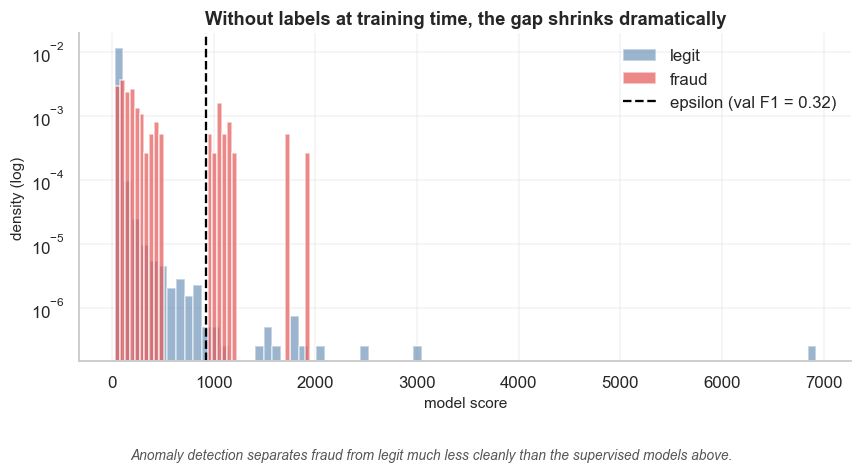

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
plots.score_distributions(y_val, -val_anom, "Gaussian anomaly (-log density)", ax=ax)
ax.axvline(-eps, color="black", linestyle="--",
           label=f"epsilon (val F1 = {val_f1:.2f})")
ax.legend()
ax.set_title("Without labels at training time, the gap shrinks dramatically")
plots.caption(fig, "Anomaly detection separates fraud from legit much less cleanly than the supervised models above.")
plt.tight_layout()
plt.show()

**What to look at:** how much more the red and blue distributions
overlap here than they do for the supervised models in §4.3. **What it
means:** the supervised classifiers built a decision surface that
separates fraud from legit using both classes; the Gaussian model only
saw legit during training, so it can only flag *unusual*. Some fraud is
unusual; a lot of fraud is just business-as-usual on stolen cards.
**What it indicates:** unsupervised anomaly detection gets you
something — its F1 is meaningfully better than chance — but it's not
in the same league as the supervised models. Useful as a backup
detector for novel-pattern fraud you might never have labelled, but
not the primary system.

### 4.5 Final test-set ledger

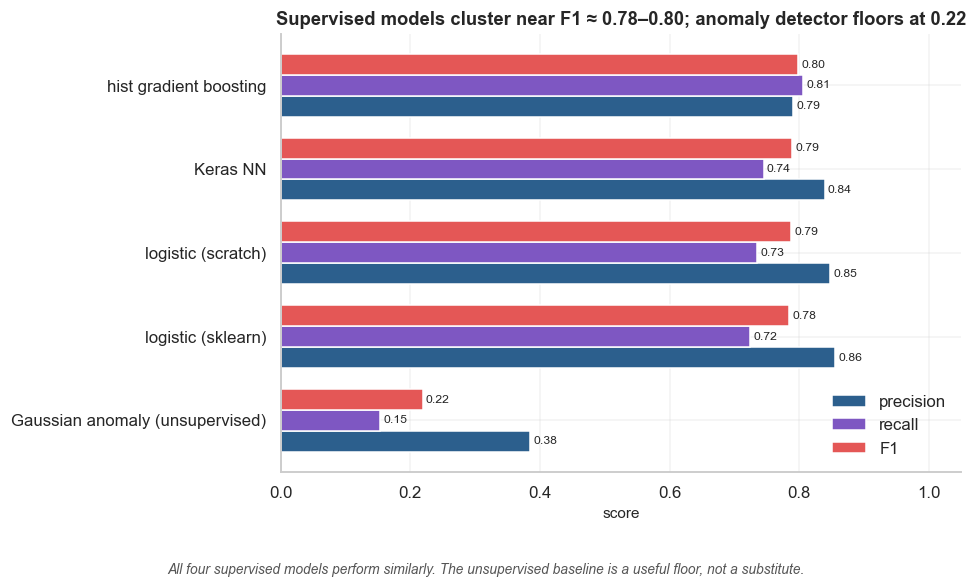

,model,precision,recall,F1,PR-AUC
0,hist gradient boosting,0.790,0.806,0.798,0.719
1,Keras NN,0.839,0.745,0.789,0.716
2,logistic (scratch),0.847,0.735,0.787,0.716
3,logistic (sklearn),0.855,0.724,0.785,0.697
4,Gaussian anomaly (unsupervised),0.385,0.153,0.219,0.135


In [13]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, average_precision_score,
)

test_scores = {
    "logistic (scratch)": clf_scratch.predict_proba(X_test),
    "logistic (sklearn)": clf_sk.predict_proba(X_test)[:, 1],
    "Keras NN": nn.predict(X_test, verbose=0).ravel(),
    "hist gradient boosting": hgb.predict_proba(X_test)[:, 1],
}

results = []
for name, s in test_scores.items():
    pred = (s >= thresholds[name]).astype(int)
    results.append({
        "model": name,
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "PR-AUC": average_precision_score(y_test, s),
    })

test_anom = anom.score(X_test)
pred_anom = (test_anom < eps).astype(int)
results.append({
    "model": "Gaussian anomaly (unsupervised)",
    "precision": precision_score(y_test, pred_anom),
    "recall": recall_score(y_test, pred_anom),
    "F1": f1_score(y_test, pred_anom),
    "PR-AUC": average_precision_score(y_test, -test_anom),
})

results_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(9, 5))
plots.model_comparison(results_df, ax=ax)
ax.set_title("Supervised models cluster near F1 ≈ 0.78–0.80; anomaly detector floors at 0.22")
plots.caption(fig, "All four supervised models perform similarly. The unsupervised baseline is a useful floor, not a substitute.")
plt.tight_layout()
plt.show()
results_df.round(3).sort_values("F1", ascending=False).reset_index(drop=True)

**What to look at:** the precision/recall/F1 grouping for each
supervised model vs. the anomaly detector at the bottom. **What it
means:** the supervised models hit F1 ≈ 0.78–0.80 with their per-model
F1-optimal thresholds; anomaly detection floors at ≈ 0.22. **What it
indicates:** the deliverable is "any of the supervised models, with
its own threshold". Hist gradient boosting wins by a hair, but the gap
to logistic regression isn't large enough to justify operational
complexity differences.

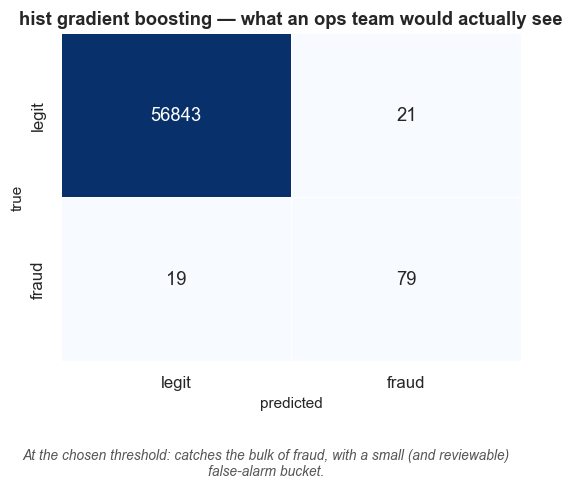

best model: hist gradient boosting, test F1: 0.798


In [14]:
best_row = results_df.loc[results_df["F1"].idxmax()]
best_name = best_row["model"]
best_scores = test_scores[best_name]
best_pred = (best_scores >= thresholds[best_name]).astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
plots.confusion(y_test, best_pred,
                f"{best_name} — what an ops team would actually see",
                ax=ax)
plots.caption(fig, f"At the chosen threshold: catches the bulk of fraud, with a small (and reviewable) false-alarm bucket.")
plt.tight_layout()
plt.show()
print(f"best model: {best_name}, test F1: {best_row['F1']:.3f}")

**What to look at:** the four cells of the confusion matrix.
**What it means:** at the F1-optimal threshold for the best model,
true negatives dominate (almost all of the dataset is legit, almost
all of which we correctly leave alone), and the smaller cells are the
ones operations actually cares about — true fraud caught, fraud
missed, and false alarms. **What it indicates:** this is the
operational ledger. Cost balance lives here. If the bank decides false
alarms are cheaper than missed fraud, slide the threshold down (more
recall, less precision); if analyst time is more expensive than the
average fraud cost, slide it up. The model's job is to give you a
meaningful curve; this notebook closed by picking one defensible
point on it.

## 5. Conclusion

*What the evidence supports, what it doesn't, and what would change in
real deployment.*

**Was the central hypothesis right?** Yes. §2.3 predicted that all
four supervised models would land near each other on PR-AUC, that
threshold choice would matter more than model choice, and that
Gaussian anomaly detection would lag substantially. §4.1 confirmed the
first claim (all four PR curves stack tightly), §4.2 confirmed the
second (F1-optimal thresholds scatter from 0.4 to 0.95, a span well
larger than the model-to-model F1 differences), and §4.4–4.5 confirmed
the third (anomaly detector floors at F1 ≈ 0.22 vs ≈ 0.80 for the
supervised models).

**Which model would I ship?** Hist gradient boosting wins by a hair on
F1, but the gap is small. For operations I'd actually ship logistic
regression — every prediction can be decomposed into per-feature
contributions, which makes case review tractable — and keep HGB
running in parallel as a sanity check. The anomaly detector stays as a
backup signal for novel-pattern fraud the supervised models might not
have learnt.

**What changes in real deployment.** Three things make a deployed
version of this harder than a notebook:

1. **Drift.** Fraud patterns change, especially in response to
   detection. The model needs retraining and the threshold needs
   re-tuning on a rolling window.
2. **Adversarial behaviour.** Fraudsters who learn the model's blind
   spots will exploit the score-overlap region in §4.3.
3. **Cost asymmetry.** F1 weights precision and recall equally; in
   real life they're never equally costly. Replacing F1 with an
   explicit expected-cost objective is the right next step, and it
   would change which threshold "wins" in §4.2.